In [1]:
import pandas as pd
df = pd.read_csv("Loan Eligibility Prediction.csv")
df.head()

,Customer_ID,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,569,Female,No,0,Graduate,No,2378,0.0,9,360,1,Urban,N
1,15,Male,Yes,2,Graduate,No,1299,1086.0,17,120,1,Urban,Y
2,95,Male,No,0,Not Graduate,No,3620,0.0,25,120,1,Semiurban,Y
3,134,Male,Yes,0,Graduate,Yes,3459,0.0,25,120,1,Semiurban,Y
4,556,Male,Yes,1,Graduate,No,5468,1032.0,26,360,1,Semiurban,Y


In [4]:
if 'df' not in globals():
	import pandas as pd
	df = pd.read_csv("Loan Eligibility Prediction.csv")

df.shape

(614, 13)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         614 non-null    int64  
 1   Gender              614 non-null    str    
 2   Married             614 non-null    str    
 3   Dependents          614 non-null    int64  
 4   Education           614 non-null    str    
 5   Self_Employed       614 non-null    str    
 6   Applicant_Income    614 non-null    int64  
 7   Coapplicant_Income  614 non-null    float64
 8   Loan_Amount         614 non-null    int64  
 9   Loan_Amount_Term    614 non-null    int64  
 10  Credit_History      614 non-null    int64  
 11  Property_Area       614 non-null    str    
 12  Loan_Status         614 non-null    str    
dtypes: float64(1), int64(6), str(6)
memory usage: 62.5 KB


In [6]:
# Show summary statistics for numerical columns
df.describe()

# Show summary statistics for categorical columns
df.describe(include='object')

# Check for missing values
df.isnull().sum()

# Display column names and data types
df.dtypes

# View unique values in each column
for col in df.columns:
    print(f"{col}: {df[col].unique()}")

Customer_ID: [569  15  95 134 556 148 271  29 583 510 611 232  47 122 401 521 342  42
 191  85  98 155 437 404 284 208 371 448 522 313 591 188 209 221 416 430
 452 584 411 169 402   3 187 408 539 182 330 358  11 133 147 336 467 514
 567 588 333 340 379 397 610 219 183  32 132 344  43 165 490  18 194 283
  41 207 278 422 487 547  73  93 124 173 361 427 200 137 311 455 557 118
 479 175 429  46 138 318 598 286 201 250 270 275 454 582 126 301 474 110
 258 529 589   7  74 171 353 364 398 499 520 543  45  57 240 304 367 425
 456 491 508  56  72 161 332 465 469  62  87 287 542  17  37  51 106 146
 216 359 385 423 435 473 502 511 523 532 177 135 180 545 400 403 549  21
  88 231 253 308 570 587 302 354 432 496  33 590 497 538 579 185 244 561
 576 609  12 399  28  40  78 296 329 375 414 424 447 468 470 493 527 533
 550 578 596  81 312 316 374 498  24  53 167 239 247 282 319 419  76 154
 199 300 386 394 395 472 482 501 517  14  34  20  99 257 276 289 321 406
 407  23  65 176 179 222 356 331 115 1

C:\Users\linhd\AppData\Local\Temp\ipykernel_52756\80556679.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\linhd\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\linhd\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Using plotting data from: loan_eligibility_sorted_by_customer_id.xlsx


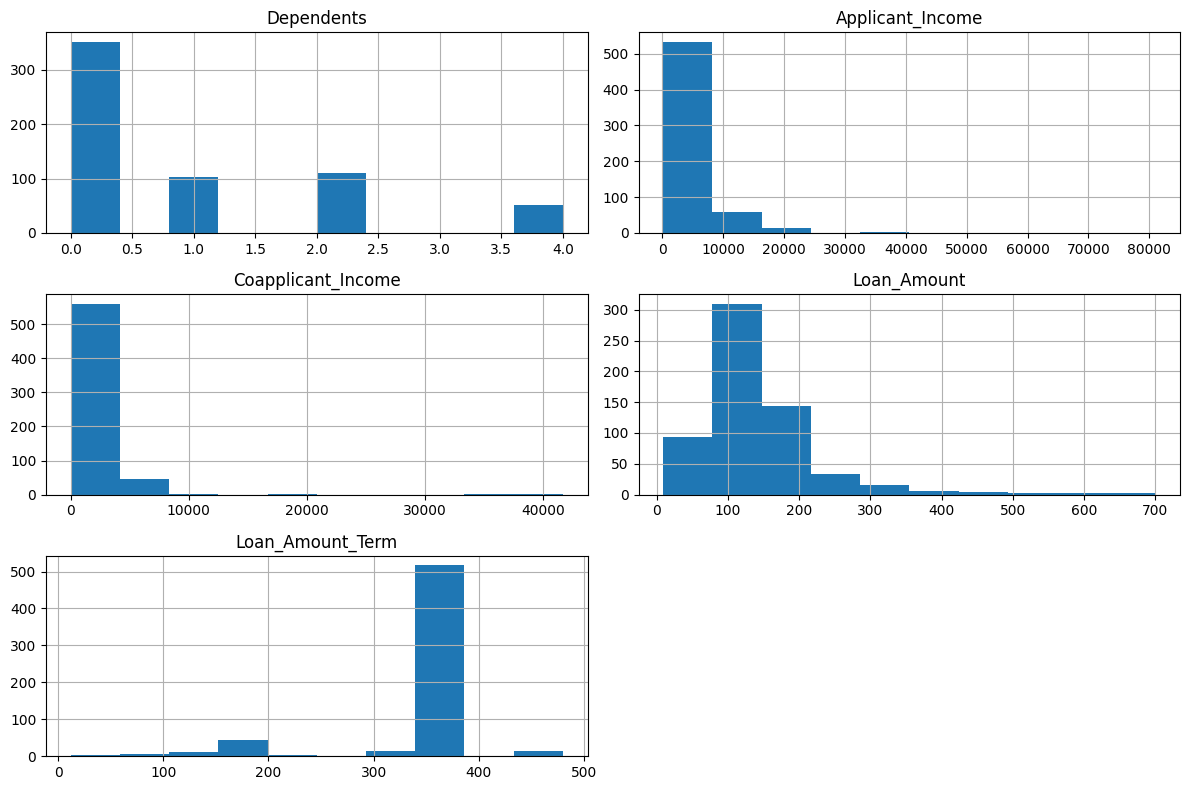

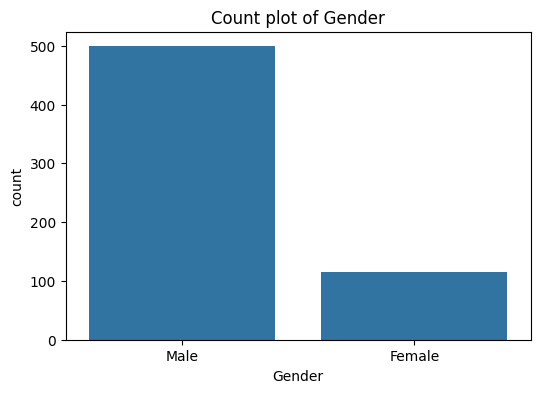

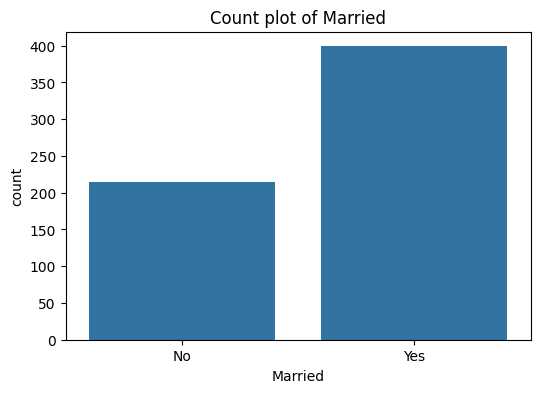

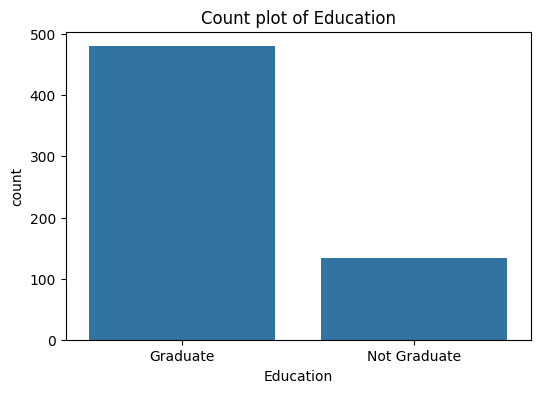

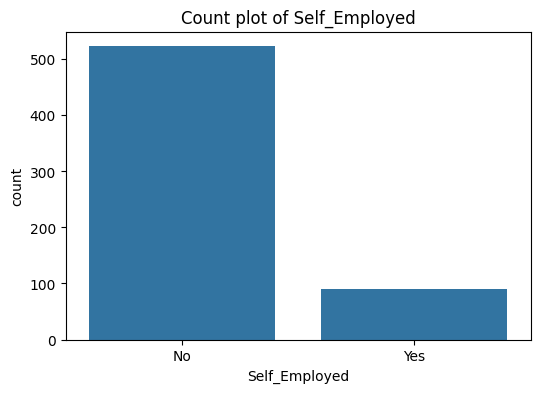

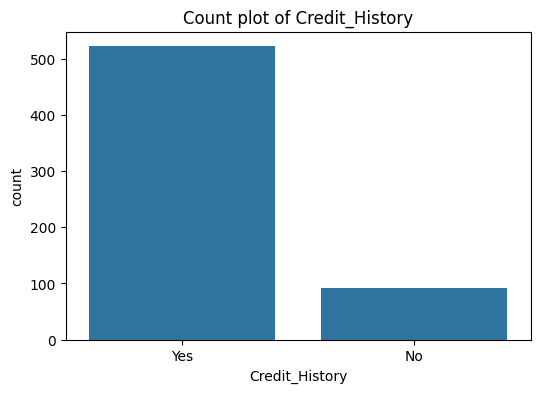

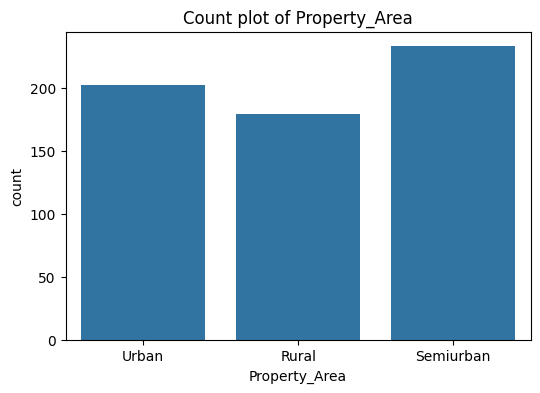

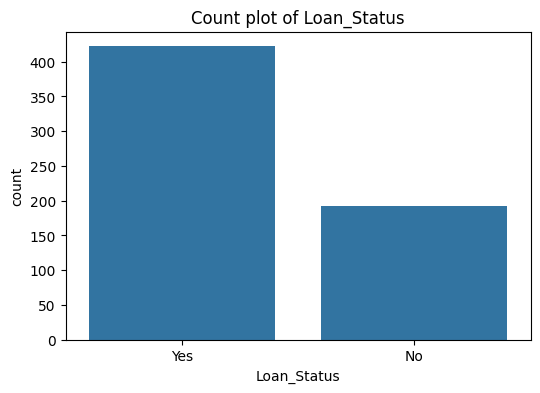

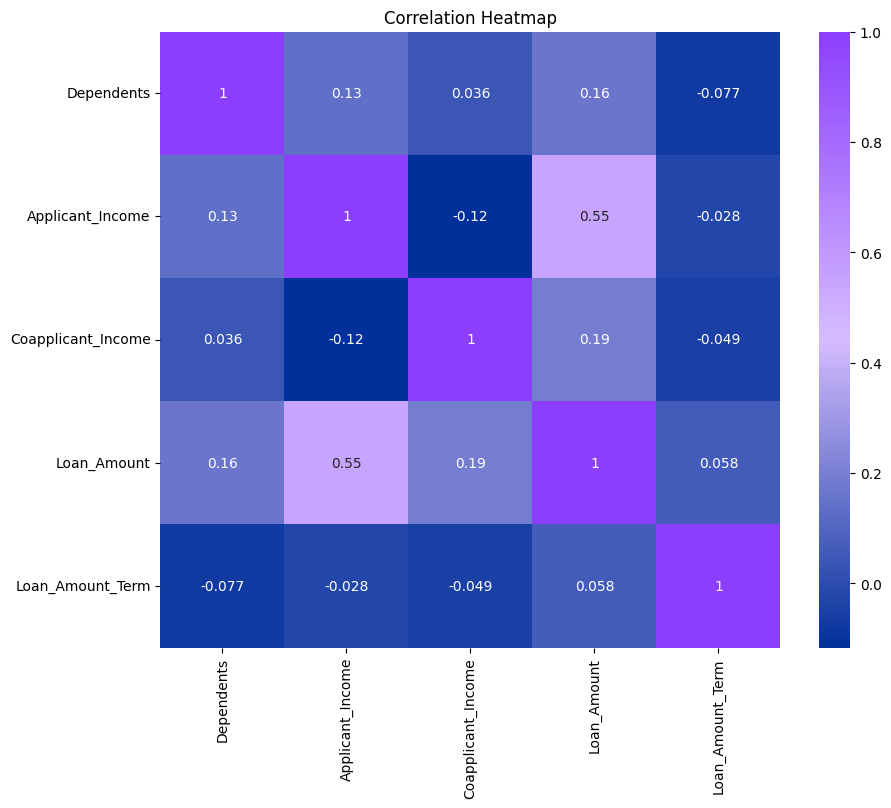

In [27]:
%pip install matplotlib
%pip install seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# Load updated Excel file for plotting
file_candidates = [
    "loan_eligibility_sorted_by_customer_id.xlsx",
    "Loan Eligibility Prediction/loan_eligibility_sorted_by_customer_id.xlsx",
]
excel_path = next((p for p in file_candidates if __import__("os").path.exists(p)), None)

if excel_path is None:
    raise FileNotFoundError("loan_eligibility_sorted_by_customer_id.xlsx not found.")

df_plot = pd.read_excel(excel_path)
print(f"Using plotting data from: {excel_path}")

# Exclude identifier column from all plots
if "Customer_ID" in df_plot.columns:
    df_plot = df_plot.drop(columns=["Customer_ID"])


# Histogram for numerical columns
df_plot.hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

# Count plots for categorical columns
categorical_cols = df_plot.select_dtypes(include=['object', 'string']).columns
for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=col, data=df_plot)
    plt.title(f'Count plot of {col}')
    plt.show()

# Correlation heatmap for numerical features
plt.figure(figsize=(10, 8))
numeric_df = df_plot.select_dtypes(include=['number'])
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap=LinearSegmentedColormap.from_list('custom_div', ['#01309A', '#D5BCFE', '#8B3EFC'])
)
plt.title('Correlation Heatmap')
plt.show()

In [10]:
#data cleaning
# Drop rows with missing target values (if any)
df = df.dropna(subset=['Loan_Status'])  # Replace 'Loan_Status' with your target column name

# Fill missing values for numerical columns with median
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fill missing values for categorical columns with mode
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Remove duplicate rows if any
df = df.drop_duplicates()

# Check results
print(df.isnull().sum())
print(df.shape)

Customer_ID           0
Gender                0
Married               0
Dependents            0
Education             0
Self_Employed         0
Applicant_Income      0
Coapplicant_Income    0
Loan_Amount           0
Loan_Amount_Term      0
Credit_History        0
Property_Area         0
Loan_Status           0
dtype: int64
(614, 13)


C:\Users\linhd\AppData\Local\Temp\ipykernel_52756\2083065657.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


In [12]:
%pip install scikit-learn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Encode categorical variables
df_encoded = df.copy()
for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col])

# Split features and target
X = df_encoded.drop('Loan_Status', axis=1)
y = df_encoded['Loan_Status']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build and train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\linhd\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


  Using cached scikit_learn-1.8.0-cp311-cp311-win_amd64.whl.metadata (11 kB)
  Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.8.0-cp311-cp311-win_amd64.whl (8.1 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl (36.6 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
Note: you may need to restart the kernel to use updated packages.
Accuracy: 0.8211382113821138
Confusion Matrix:
 [[19 21]
 [ 1 82]]
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.47      0.63        40
           1       0.80      0.99      0.88        83

    accuracy                           0.82       123
   macro avg       0.87      0.73      0.76       123
weighted avg       0.85      0.82      0.80       12

C:\Users\linhd\AppData\Local\Temp\ipykernel_52756\443962641.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_encoded.select_dtypes(include='object').columns:
C:\Users\linhd\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want t

In [13]:
# Get feature importance from the trained model and encoded features
feature_importance = pd.Series(model.coef_[0], index=X.columns).sort_values(ascending=False)
print(feature_importance)

Credit_History        2.912138
Married               0.484211
Customer_ID           0.000193
Applicant_Income      0.000015
Coapplicant_Income   -0.000049
Loan_Amount          -0.001988
Loan_Amount_Term     -0.003816
Property_Area        -0.010803
Dependents           -0.011248
Self_Employed        -0.051727
Gender               -0.275820
Education            -0.580342
dtype: float64


Loan Status Distribution (%)
Loan_Status  Percentage
          Y       68.73
          N       31.27


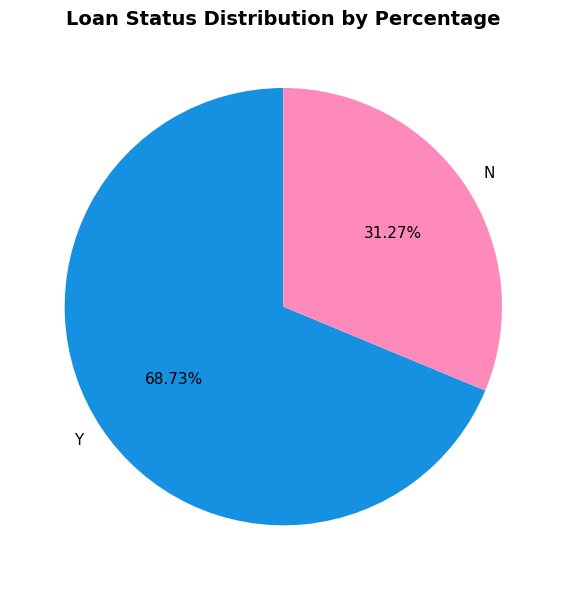

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure df exists even if this cell is run independently
if 'df' not in globals():
    if 'pd' not in globals():
        import pandas as pd
    df = pd.read_csv("Loan Eligibility Prediction.csv")

loan_status_pct = (
    df['Loan_Status']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename_axis('Loan_Status')
    .reset_index(name='Percentage')
)

print('Loan Status Distribution (%)')
print(loan_status_pct.to_string(index=False))

plt.figure(figsize=(8, 6))
colors = ['#1691E1', '#FE8ABB']
plt.pie(loan_status_pct['Percentage'], 
        labels=loan_status_pct['Loan_Status'], 
        autopct='%1.2f%%',
        colors=colors,
        startangle=90,
        textprops={'fontsize': 11})
plt.title('Loan Status Distribution by Percentage', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

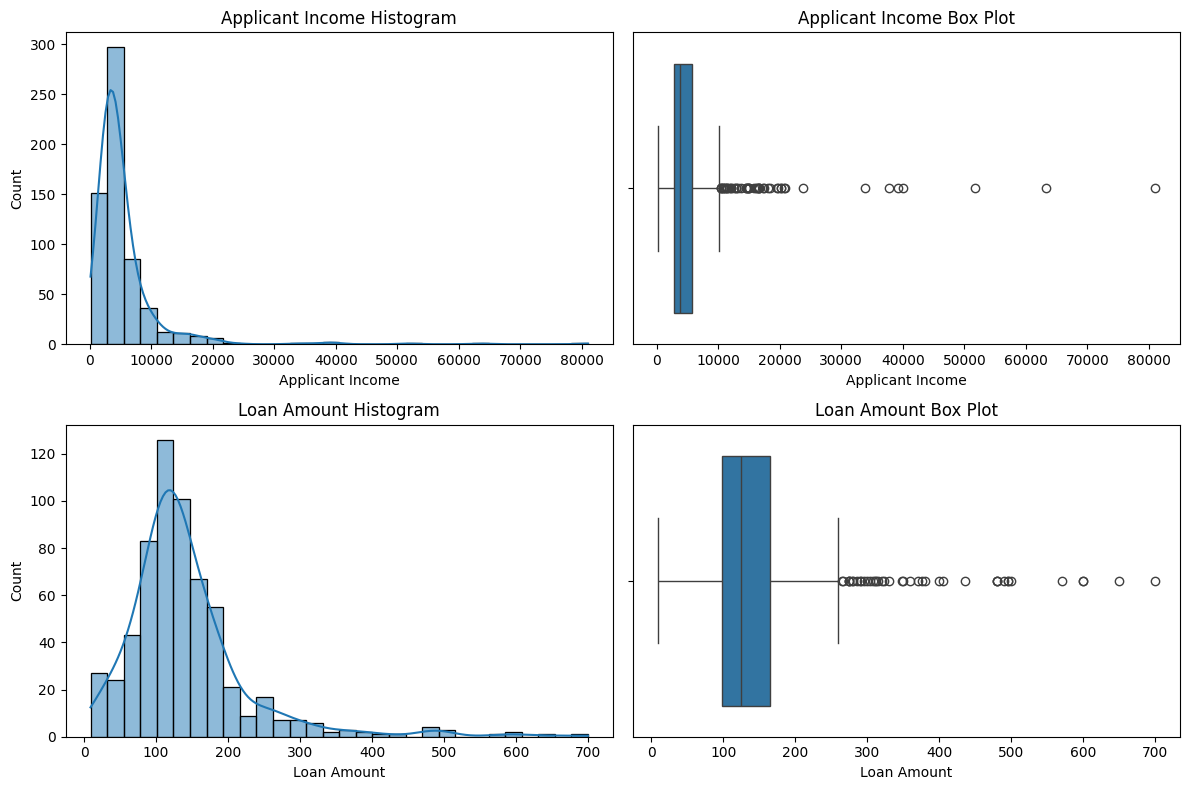

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(df['Applicant_Income'], bins=30, kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Applicant Income Histogram')
axes[0, 0].set_xlabel('Applicant Income')

sns.boxplot(x=df['Applicant_Income'], ax=axes[0, 1])
axes[0, 1].set_title('Applicant Income Box Plot')
axes[0, 1].set_xlabel('Applicant Income')

sns.histplot(df['Loan_Amount'], bins=30, kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Loan Amount Histogram')
axes[1, 0].set_xlabel('Loan Amount')

sns.boxplot(x=df['Loan_Amount'], ax=axes[1, 1])
axes[1, 1].set_title('Loan Amount Box Plot')
axes[1, 1].set_xlabel('Loan Amount')

plt.tight_layout()
plt.show()

Key ratio summary:
       Installment_to_Income_Ratio  Loan_to_Annual_Income_Ratio
count                      614.000                      614.000
mean                         0.125                        3.098
std                          0.245                        4.595
min                          0.003                        0.101
25%                          0.065                        1.899
50%                          0.088                        2.537
75%                          0.126                        3.483
max                          4.674                       75.000


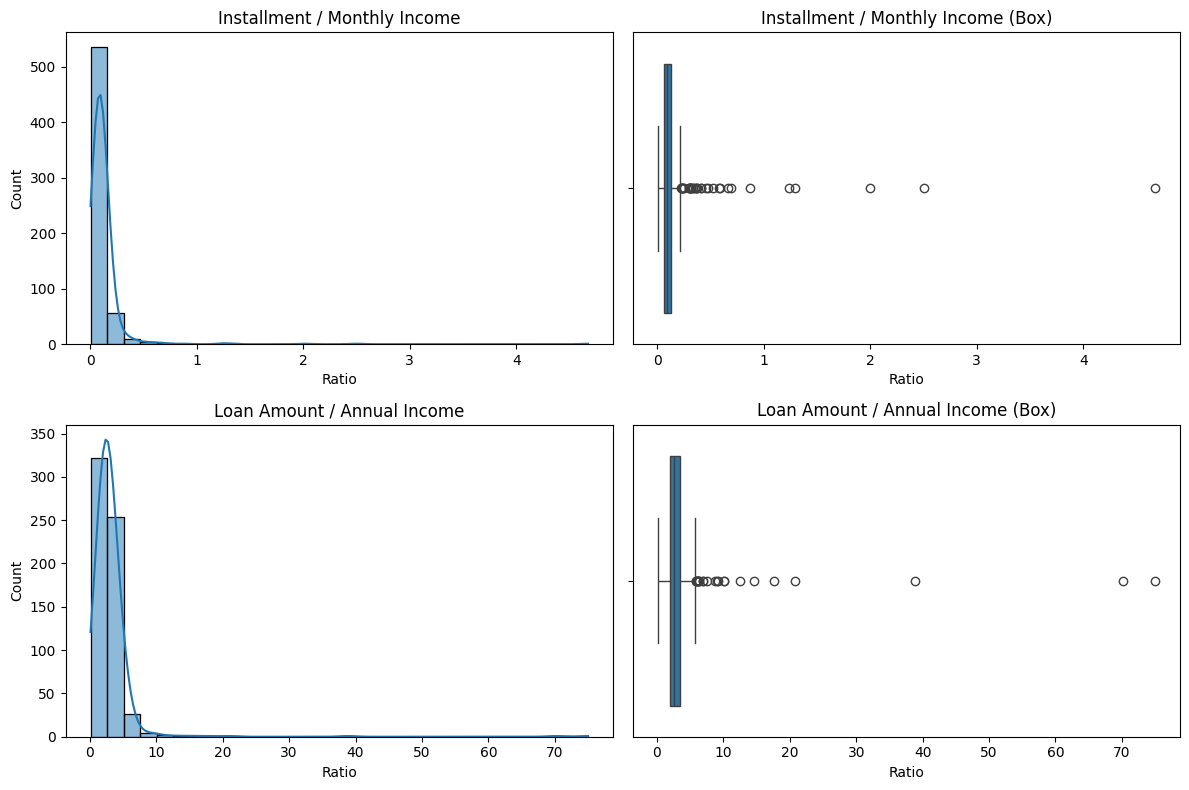

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Clear ratio metrics using amount + term + income
ratio_df = df.copy()

# Assumption: Loan_Amount is in thousands and Applicant_Income is monthly
ratio_df['Loan_Amount_Full'] = ratio_df['Loan_Amount'] * 1000
ratio_df['Term_Months'] = ratio_df['Loan_Amount_Term']

# Monthly loan burden relative to monthly income
ratio_df['Estimated_Monthly_Installment'] = ratio_df['Loan_Amount_Full'] / ratio_df['Term_Months']
ratio_df['Installment_to_Income_Ratio'] = ratio_df['Estimated_Monthly_Installment'] / ratio_df['Applicant_Income']

# Total loan amount relative to annual income
ratio_df['Annual_Income'] = ratio_df['Applicant_Income'] * 12
ratio_df['Loan_to_Annual_Income_Ratio'] = ratio_df['Loan_Amount_Full'] / ratio_df['Annual_Income']

# Clean invalid values
for col in ['Installment_to_Income_Ratio', 'Loan_to_Annual_Income_Ratio']:
    ratio_df[col] = ratio_df[col].replace([np.inf, -np.inf], np.nan)

ratio_df = ratio_df.dropna(subset=['Installment_to_Income_Ratio', 'Loan_to_Annual_Income_Ratio'])

print('Key ratio summary:')
print(ratio_df[['Installment_to_Income_Ratio', 'Loan_to_Annual_Income_Ratio']].describe().round(3))

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(ratio_df['Installment_to_Income_Ratio'], bins=30, kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Installment / Monthly Income')
axes[0, 0].set_xlabel('Ratio')

sns.boxplot(x=ratio_df['Installment_to_Income_Ratio'], ax=axes[0, 1])
axes[0, 1].set_title('Installment / Monthly Income (Box)')
axes[0, 1].set_xlabel('Ratio')

sns.histplot(ratio_df['Loan_to_Annual_Income_Ratio'], bins=30, kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Loan Amount / Annual Income')
axes[1, 0].set_xlabel('Ratio')

sns.boxplot(x=ratio_df['Loan_to_Annual_Income_Ratio'], ax=axes[1, 1])
axes[1, 1].set_title('Loan Amount / Annual Income (Box)')
axes[1, 1].set_xlabel('Ratio')

plt.tight_layout()
plt.show()

In [ ]:
# Risk bands for repayment burden using installment-to-income ratio
# Common rule-of-thumb style bands
band_labels = ['Low (<20%)', 'Medium (20-40%)', 'High (>40%)']
ratio_df['Repayment_Risk_Band'] = pd.cut(
    ratio_df['Installment_to_Income_Ratio'],
    bins=[-np.inf, 0.20, 0.40, np.inf],
    labels=band_labels
)

band_table = (
    ratio_df['Repayment_Risk_Band']
    .value_counts(dropna=False)
    .rename_axis('Risk_Band')
    .reset_index(name='Count')
)
band_table['Percentage'] = (band_table['Count'] / band_table['Count'].sum() * 100).round(2)

print('Repayment Risk Band Summary')
print(band_table.to_string(index=False))

plt.figure(figsize=(7, 4))
sns.barplot(data=band_table, x='Risk_Band', y='Percentage', hue='Risk_Band', legend=False)
plt.title('Repayment Risk Bands (Installment / Monthly Income)')
plt.xlabel('Risk Band')
plt.ylabel('Percentage (%)')
plt.tight_layout()
plt.show()

Loan Status % within each Repayment Risk Band
Loan_Status              N      Y
Repayment_Risk_Band              
Low (<20%)           30.05  69.95
Medium (20-40%)      46.67  53.33
High (>40%)          46.67  53.33


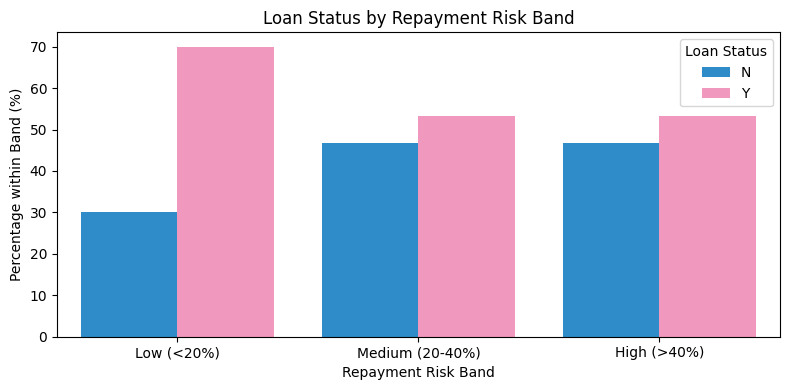

In [23]:
# Approval rate by repayment risk band
approval_table = pd.crosstab(
    ratio_df['Repayment_Risk_Band'],
    ratio_df['Loan_Status'],
    normalize='index'
).mul(100).round(2)

print('Loan Status % within each Repayment Risk Band')
print(approval_table)

approval_long = approval_table.reset_index().melt(
    id_vars='Repayment_Risk_Band',
    var_name='Loan_Status',
    value_name='Percentage'
)

# Exact two-color palette requested
status_palette = {'N': '#1691E1', 'Y': '#FE8ABB', 0: '#1691E1', 1: '#FE8ABB'}

plt.figure(figsize=(8, 4))
sns.barplot(
    data=approval_long,
    x='Repayment_Risk_Band',
    y='Percentage',
    hue='Loan_Status',
    palette=status_palette
 )
plt.title('Loan Status by Repayment Risk Band')
plt.xlabel('Repayment Risk Band')
plt.ylabel('Percentage within Band (%)')
plt.legend(title='Loan Status')
plt.tight_layout()
plt.show()

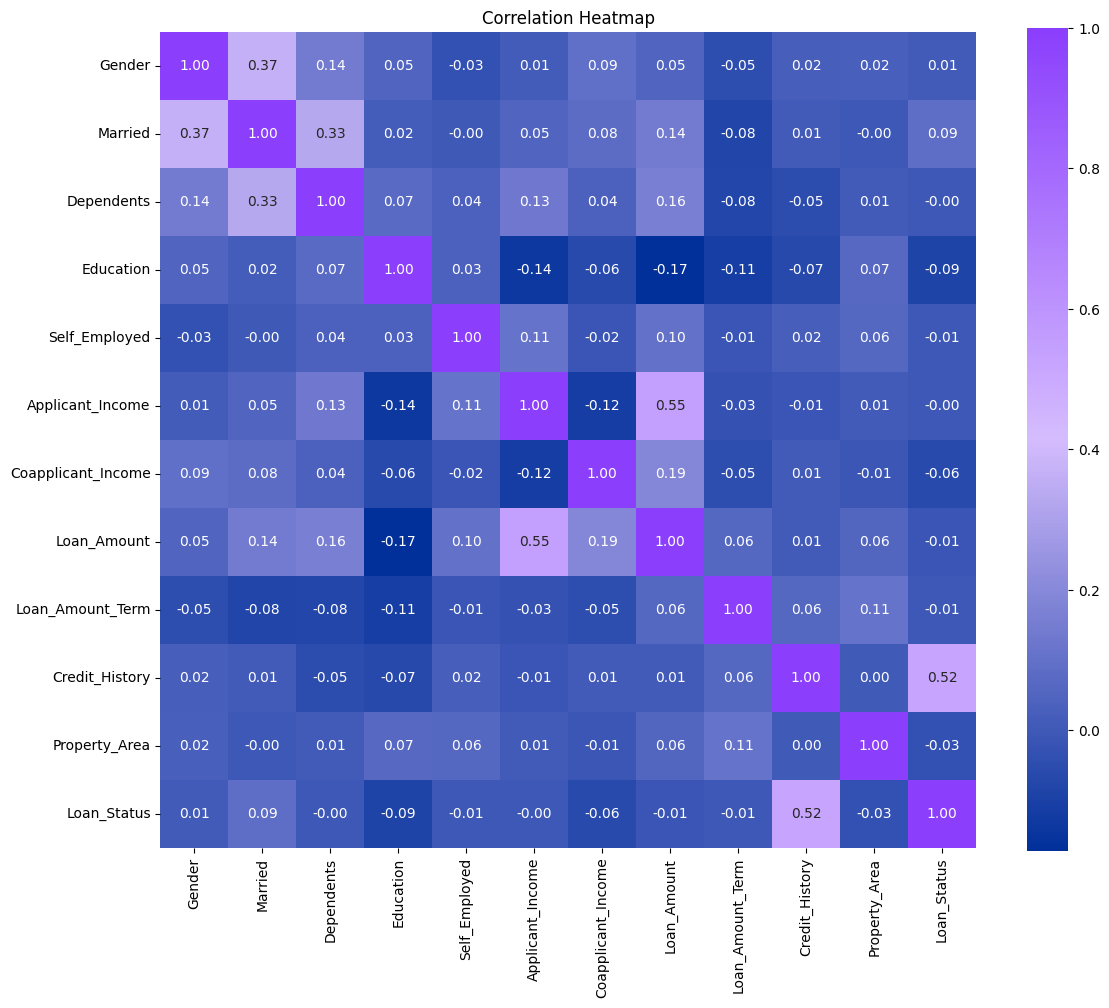

In [17]:
from matplotlib.colors import LinearSegmentedColormap
# Correlation heatmap with all variables except Customer_ID (categoricals encoded)
corr_df = df.copy()

if 'Customer_ID' in corr_df.columns:
    corr_df = corr_df.drop(columns=['Customer_ID'])

for col in corr_df.columns:
    if not pd.api.types.is_numeric_dtype(corr_df[col]):
        corr_df[col] = pd.factorize(corr_df[col])[0]

corr_df = corr_df.apply(pd.to_numeric, errors='coerce')
corr_matrix = corr_df.corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap=LinearSegmentedColormap.from_list('custom_div', ['#01309A', '#D5BCFE', '#8B3EFC']), square=True)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

C:\Users\linhd\AppData\Local\Temp\ipykernel_60700\1838640423.py:19: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_model.select_dtypes(include='object').columns:
C:\Users\linhd\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to

ANALYSIS 1: MULTIVARIATE APPROVAL DRIVERS

Top factors affecting loan approval (positive = increases approval, negative = decreases approval):

           Feature  Coefficient  Abs_Coefficient
    Credit_History     3.048012         3.048012
           Married     0.606605         0.606605
         Education    -0.438262         0.438262
            Gender    -0.370975         0.370975
     Self_Employed    -0.163400         0.163400
     Property_Area     0.039902         0.039902
        Dependents    -0.012069         0.012069
  Loan_Amount_Term    -0.002745         0.002745
       Loan_Amount    -0.000799         0.000799
Coapplicant_Income    -0.000059         0.000059
  Applicant_Income    -0.000004         0.000004


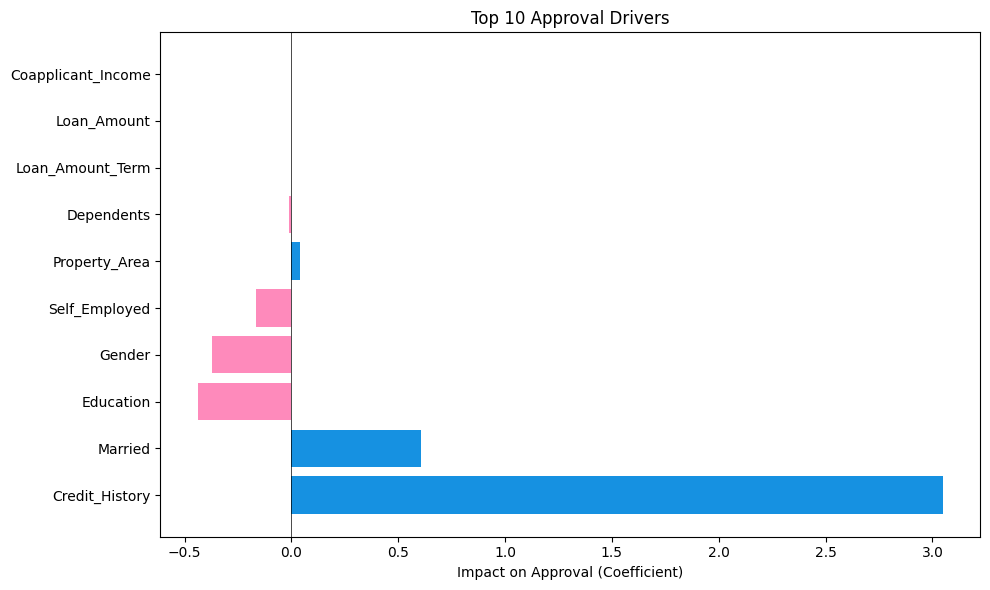


📊 INTERPRETATION:
   - GREEN bars: Increase approval chances
   - RED bars: Decrease approval chances
   - Longer bars = stronger effect


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression

# Ensure df exists even if this cell is run independently
if 'df' not in globals():
    df = pd.read_csv("Loan Eligibility Prediction.csv")

# Prepare data for logistic regression
df_model = df.copy()

# Drop Customer_ID if present
if 'Customer_ID' in df_model.columns:
    df_model = df_model.drop(columns=['Customer_ID'])

# Encode all categorical variables
for col in df_model.select_dtypes(include='object').columns:
    df_model[col] = LabelEncoder().fit_transform(df_model[col])

# Prepare features and target
X = df_model.drop('Loan_Status', axis=1)
y = df_model['Loan_Status']

# Fit logistic regression model
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X, y)

# Get coefficients (importance)
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_reg.coef_[0],
    'Abs_Coefficient': np.abs(log_reg.coef_[0])
}).sort_values('Abs_Coefficient', ascending=False)

print("=" * 60)
print("ANALYSIS 1: MULTIVARIATE APPROVAL DRIVERS")
print("=" * 60)
print("\nTop factors affecting loan approval (positive = increases approval, negative = decreases approval):\n")
print(importance.to_string(index=False))

# Visualize
plt.figure(figsize=(10, 6))
top_features = importance.head(10)
colors = [''#1691E1 if x > 0 else '#FE8ABB' for x in top_features['Coefficient']]
plt.barh(top_features['Feature'], top_features['Coefficient'], color=colors)
plt.xlabel('Impact on Approval (Coefficient)')
plt.title('Top 10 Approval Drivers')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

print("\n📊 INTERPRETATION:")
print("   - GREEN bars: Increase approval chances")
print("   - RED bars: Decrease approval chances")
print("   - Longer bars = stronger effect")
